# Sentiment Analysis on Product Reviews

## Task 1: Data Loading & Exploration

import pandas as pd

df = pd.read_csv("Reviews.csv", engine="python", error_bad_lines=False)
df.head()

In [8]:
import pandas as pd

df = pd.read_csv("Reviews.csv", engine="python", on_bad_lines='skip')

# Limit to 5000 rows
df = df.head(5000)

df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [9]:
df.shape

(5000, 10)

## Task 2: Data Cleaning

In [10]:
# Keep only required columns
df = df[['Text', 'Score']]

# Remove null values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

# Reset index
df = df.reset_index(drop=True)

df.head()

,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5


## Task 3: Sentiment Analysis

In [12]:
!pip install textblob

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
     |████████████████████████████████| 624 kB 17.3 MB/s eta 0:00:01
     |████████████████████████████████| 1.5 MB 14.3 MB/s eta 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [13]:
!python -m textblob.download_corpora

[nltk_data] Downloading package brown to
[nltk_data]     /home/6219e206-38e5-4f1b-904d-730cce30fc99/nltk_data..
[nltk_data]     .
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/6219e206-38e5-4f1b-904d-730cce30fc99/nltk_data..
[nltk_data]     .
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/6219e206-38e5-4f1b-904d-730cce30fc99/nltk_data..
[nltk_data]     .
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/6219e206-38e5-4f1b-904d-730cce30fc99/nltk_data..
[nltk_data]     .
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to
[nltk_data]     /home/6219e206-38e5-4f1b-904d-730cce30fc99/nltk_data..
[nltk_data]     .
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to
[nltk_data]     /home/6219e206-38e5-4f1b-904d-730cce30fc99

In [1]:
from textblob import TextBlob

In [3]:
import pandas as pd

df = pd.read_csv("Reviews.csv", engine="python", on_bad_lines='skip')

# Limit rows
df = df.head(5000)

In [4]:
df = df[['Text', 'Score']]
df = df.dropna()
df = df.drop_duplicates()
df = df.reset_index(drop=True)

In [5]:
from textblob import TextBlob

In [6]:
df['Polarity'] = df['Text'].apply(lambda x: TextBlob(x).sentiment.polarity)

In [7]:
def label_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['Sentiment'] = df['Polarity'].apply(label_sentiment)

## Task 4: Data Visualization

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [10]:
import os
os.makedirs("charts", exist_ok=True)

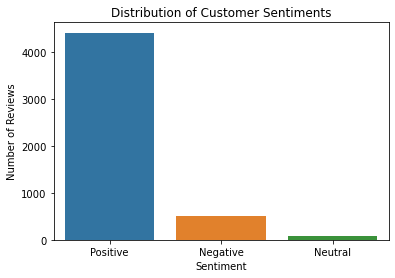

In [22]:
sns.countplot(x='Sentiment', data=df)
plt.title("Distribution of Customer Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.savefig("charts/bar_chart.png")
plt.show()

In [12]:
import os
os.listdir()

['.local',
 '.gitconfig',
 '.anaconda',
 '.vimrc',
 '.config',
 '.ipynb_checkpoints',
 'anaconda_projects',
 'Reviews.csv',
 '.bashrc',
 'nltk_data',
 '.virtualenvs',
 '.npm',
 'README.ipynb',
 'charts',
 '.profile',
 '.conda',
 'analysis.ipynb',
 '.cache',
 '.jupyter',
 '.pythonstartup.py',
 '.ipython']

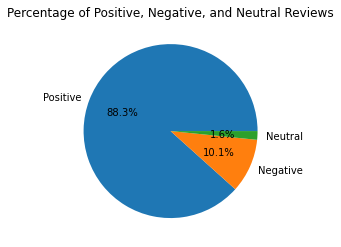

In [23]:
df['Sentiment'].value_counts().plot.pie(autopct='%1.1f%%')

plt.title("Percentage of Positive, Negative, and Neutral Reviews")
plt.ylabel("")

plt.savefig("charts/pie_chart.png")
plt.show()

In [15]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
     |████████████████████████████████| 525 kB 22.1 MB/s eta 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [16]:
from wordcloud import WordCloud

In [20]:
!pip install Counter

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
  Created wheel for Counter: filename=Counter-1.0.0-py3-none-any.whl size=5411 sha256=71d7358b9a1a983ecebe78699196c98c997add0ce81a0efea608ab9f720d82e3
  Stored in directory: /home/6219e206-38e5-4f1b-904d-730cce30fc99/.cache/pip/wheels/8c/53/bd/a2a81742d0585769e6f7304ccafdd9d85b828371602b103728
Successfully built Counter


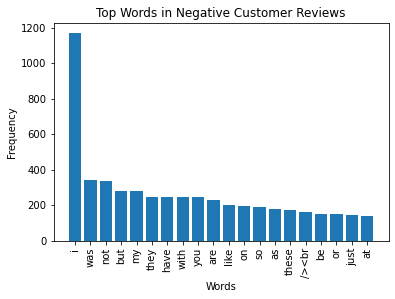

In [24]:
from collections import Counter
import matplotlib.pyplot as plt

# Get negative reviews text
negative_words = " ".join(df[df['Sentiment'] == 'Negative']['Text']).lower().split()

# Remove very common useless words (optional but better)
stopwords = ['the', 'and', 'a', 'to', 'of', 'it', 'is', 'in', 'for', 'this', 'that']
filtered_words = [word for word in negative_words if word not in stopwords]

# Get most common words
common_words = Counter(filtered_words).most_common(20)

words, counts = zip(*common_words)

# Plot
plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.title("Top Words in Negative Customer Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.savefig("charts/word_frequency.png")
plt.show()

In [ ]:
import shutil

shutil.make_archive("SentimentAnalysis_Itrat", 'zip', ".")